# Time Series Forecasting — Introduction and Data Preprocessing

*From raw hourly data to model-ready windows*

## Welcome

This notebook lays the foundations for the rest of the deep-learning forecasting work. Our central question is:

> *Given the last *T* hours of pollutant + weather observations at a Beijing air-quality station, what will PM2.5 (or O&#8323;) be 1, 6, or 12 hours from now?*

This is **supervised time-series forecasting**. Supervised because we have inputs (the past window) and a target (the future value). Time-series because the inputs **are** temporally ordered, and that order is something we cannot break — we'll see why in a moment.

**By the end of this notebook** you will have:

1. Framed forecasting as a sliding-window supervised problem.
2. Engineered **cyclic time encodings** (hour, month, day-of-week as sin/cos pairs) and **wind direction** as east-west and north-south components.
3. Built a **15-feature input set** — target history, wind speed and direction, four meteo channels, NO&#8322;, and six cyclic time features — each with a clear physical role.
4. Built **gap-aware sliding windows** of *T* = 24 hours from the engineered series.
5. Split the data **chronologically** (no leakage from the future).
6. Standardised features and target using **train-only** statistics.

After this notebook you'll have a clean preprocessing chain that any forecasting model can plug into. **Predictions and metrics start in the next notebook**, where we set up naive baselines.

---
## 1. Describing vs predicting — what changes?

Before we touch any data, two different questions one could ask of an air-quality dataset:

- **"What patterns are in this data?"** — find clusters, components, anomalies. That's the **describing** mode, used by methods like PCA, K-means or DBSCAN.
- **"What will PM2.5 be one hour from now?"** — produce a number for a future timestamp. That's the **predicting** mode, our setting from this notebook onwards.

Same data, completely different setup. Here is what changes:

| Aspect | Describing (e.g. clustering, PCA) | Predicting (forecasting) |
|---|---|---|
| Question | What structure exists in the data? | What value comes next? |
| Output | Cluster labels, components, anomaly flags | Numeric prediction (e.g. PM2.5 in &micro;g/m&sup3;) |
| Evaluation | Interpretability, silhouette, stability | MAE / RMSE / R&sup2; on a held-out test set |
| Treats time as | Just another column (or ignored) | The **central** axis — causality and leakage matter |

The biggest practical change is the last row. For descriptive tasks we can shuffle rows, drop rows, sample at random — order doesn't matter. For forecasting, **we cannot do any of that** without invalidating the experiment.

---
## 2. The forecasting setup — sliding windows and horizons

**Analogy.** Imagine you carry a small **24-hour weather diary** in your pocket. At any moment you can flip to the last day's pages and see what happened — temperature, wind, rain. Based on that diary, you make a forecast for some time in the future.

That is exactly our setup. At every hour *t*, we form:

- **Input** **x**<sub>t</sub>: the last *T* hours of observations — a window from time *t*−*T*+1 to *t* with our chosen features.
- **Target** *y*<sub>t+h</sub>: the value of the chosen pollutant ***h* hours after** the window ends.
- **Goal**: learn *f*(**x**<sub>t</sub>) ≈ *y*<sub>t+h</sub>.

Two hyper-parameters:

- **T** — window length. We will use *T* = 24 (one full daily cycle of context). Wide enough to see day-vs-night, narrow enough that windows fit easily into memory.
- **h** — forecast horizon. We will care about *h* ∈ {1, 6, 12} hours.

The schematic below shows one such (window, target) example. The grey curve is a generic time series; the **blue band** is one 24-hour input window ending at the current time *t*; the **coloured dots** mark the target values we'd want to forecast at three different horizons.

In [1]:
# Standard scientific stack + our forecasting helper module.
# We import once here and reuse the same symbols throughout the notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import forecasting_utils as fu

np.random.seed(0)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

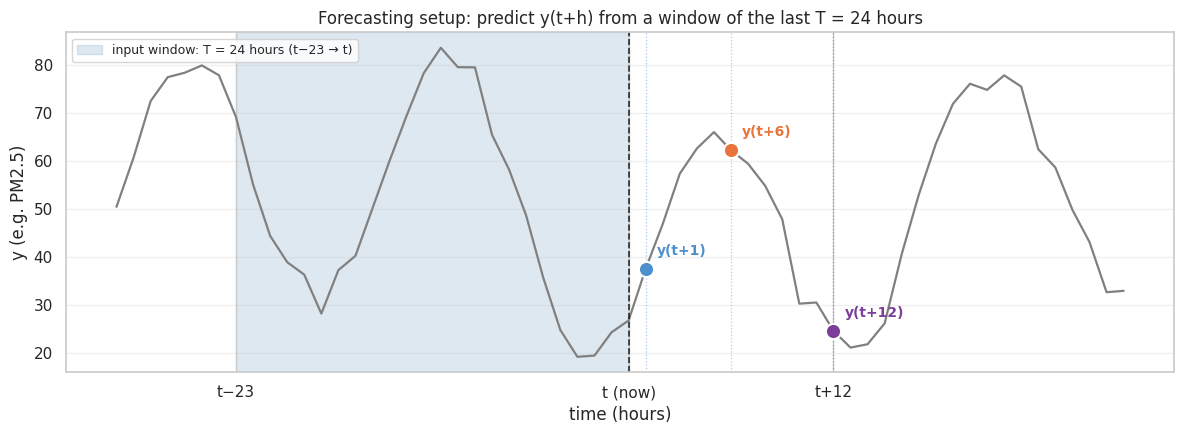

In [2]:
# Schematic of the forecasting setup on a synthetic time series
n_points = 60
xs = np.arange(n_points)
rng = np.random.default_rng(0)
ys = 50 + 25 * np.sin(0.4 * xs) + 10 * np.sin(0.13 * xs) + rng.normal(0, 3, size=n_points)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(xs, ys, color="gray", linewidth=1.6, zorder=1)

T_demo = 24
t_now = 30
win_start = t_now - T_demo + 1
ax.axvspan(win_start, t_now, color="steelblue", alpha=0.18,
           zorder=0, label=f"input window: T = {T_demo} hours (t−{T_demo-1} → t)")

ax.axvline(t_now, color="black", linestyle="--", linewidth=1.2, alpha=0.8)

horizons = [(1, "#4E8FCE"), (6, "#E8743B"), (12, "#7B3F99")]
for h, color in horizons:
    t_target = t_now + h
    val = ys[t_target]
    ax.scatter([t_target], [val], s=120, color=color, zorder=3,
               edgecolor="white", linewidth=1.5)
    ax.annotate(f"y(t+{h})", (t_target, val), textcoords="offset points",
                xytext=(8, 10), fontsize=10, color=color, fontweight="bold")
    ax.axvline(t_target, color=color, linestyle=":", linewidth=0.9, alpha=0.5)

ax.set_xticks([win_start, t_now, t_now + 12])
ax.set_xticklabels([f"t−{T_demo-1}", "t (now)", "t+12"])
ax.set_ylabel("y (e.g. PM2.5)")
ax.set_xlabel("time (hours)")
ax.set_title("Forecasting setup: predict y(t+h) from a window of the last T = 24 hours")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

Read the figure as a single training example: the model sees the **blue band** (24 hours of inputs ending at *t*) and is asked to predict the value at the **coloured dot** for the chosen horizon. The same pattern then slides one hour forward, giving another (window, target) pair — and so on across the full time series.

---
## 3. Loading the data

We use the **Beijing Multi-Site Air-Quality dataset** — hourly observations from **12 monitoring stations** across Beijing between **1 March 2013 and 28 February 2017** (≈35 000 hours per station, ≈420 000 records in total). On disk the CSV files use the prefix `PRSA_Data_*` after *Proceedings of the Royal Society A*, the journal where the original analysis was published — that's why you will see "PRSA" in filenames and code paths.

We focus on a single station, **Nongzhanguan** (a residential urban site in eastern Beijing), for one practical reason:

> **Lowest missing-value rate** of the twelve stations (≈5.4 %). Forecasting is more sensitive to gaps than descriptive methods — every gap costs us valid sliding windows — so we start from the cleanest station.

The helper `load_clean_station` reads the CSV, parses the datetime, sorts chronologically, and **drops rows** with any missing value in the eleven numeric features (six pollutants + five meteo). No imputation: gaps stay gaps, and our windowing logic later will respect them. The CSV also contains a categorical wind-direction column **`wd`** (a 16-point compass: N, NNE, NE, …) which we keep raw for now and turn into two numeric features in Section 5.

> **Reference.** Zhang et al., *Cautionary tales on air-quality improvement in Beijing*, Proc. Royal Soc. A, 2017. The dataset is publicly available via the UCI Machine Learning Repository: [archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data).

In [3]:
df = fu.load_clean_station("Nongzhanguan")

print(f"Rows after dropna : {len(df):,}")
print(f"Time span         : {df['datetime'].min()}  ->  {df['datetime'].max()}")
print(f"Numeric features  : {fu.FEATURES_BASIC}")
print(f"Categorical kept  : 'wd' (wind direction)  -- decomposed later in \u00a75")
print(f"Unique wd values  : {sorted(df['wd'].dropna().unique())}")

Rows after dropna : 33,176
Time span         : 2013-03-01 00:00:00  ->  2017-02-28 23:00:00
Numeric features  : ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
Categorical kept  : 'wd' (wind direction)  -- decomposed later in §5
Unique wd values  : ['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW']


About 33,000 hourly observations across four years. Let's quickly look at our two forecasting targets — **PM2.5** and **O&#8323;** — over a 27-day stretch known to be gap-free, so the curves show their true rhythm:

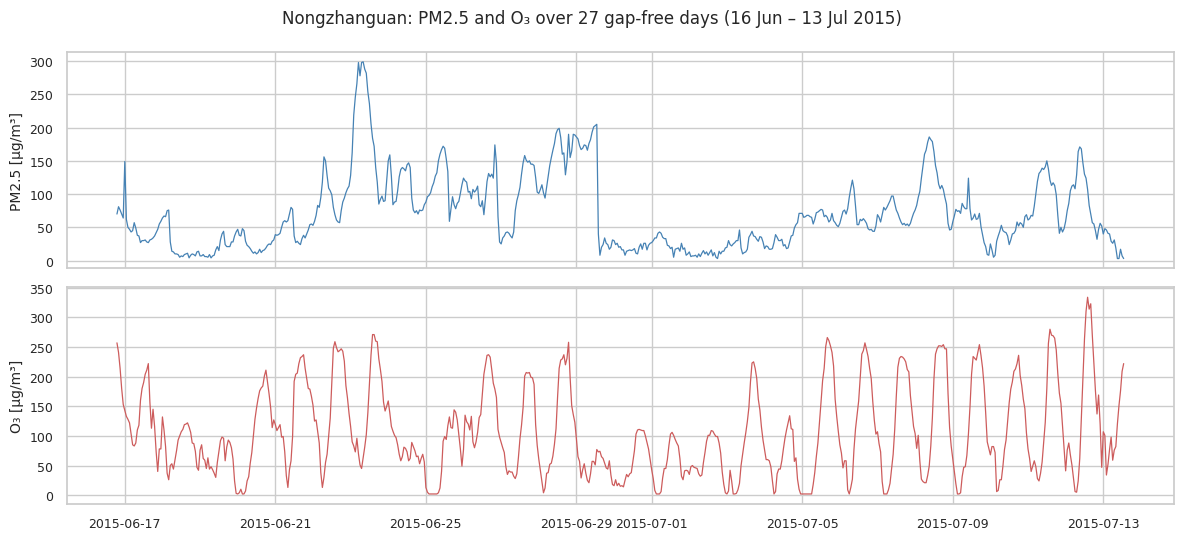

In [4]:
# Longest gap-free run in the cleaned data: 16 Jun 2015 19:00 -> 13 Jul 2015 13:00
start = pd.Timestamp("2015-06-16 19:00")
end   = pd.Timestamp("2015-07-13 13:00")
slice_df = df[(df["datetime"] >= start) & (df["datetime"] <= end)]

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
fig.suptitle("Nongzhanguan: PM2.5 and O\u2083 over 27 gap-free days (16 Jun \u2013 13 Jul 2015)",
             fontsize=12)

axes[0].plot(slice_df["datetime"], slice_df["PM2.5"], color="steelblue", linewidth=0.9)
axes[0].set_ylabel("PM2.5 [\u00b5g/m\u00b3]", fontsize=10)
axes[0].tick_params(axis="both", labelsize=9)

axes[1].plot(slice_df["datetime"], slice_df["O3"], color="indianred", linewidth=0.9)
axes[1].set_ylabel("O\u2083 [\u00b5g/m\u00b3]", fontsize=10)
axes[1].tick_params(axis="both", labelsize=9)
axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

Even from this 27-day slice, two different *temporal personalities* are visible:

- **PM2.5** moves in **episodes** that last a day or several days. Big spikes appear and decay; the daily rhythm is much weaker than the episodic rhythm. This is a particle pollutant whose level depends on emissions + wind-driven dispersion — both slow processes.
- **O&#8323;** has a striking **daily cycle**: low at night, peak in early afternoon, back down by evening. This is photochemistry — ozone is produced under sunlight from NO&#8322; precursors, so it tracks the sun.

Hold on to that distinction. We'll see it again and again: a method that works well for one pollutant can fail for the other purely because of this difference.

---
## 4. Cyclic time features — putting hour 23 next to hour 0

Before we slice the data into supervised (window, target) pairs, we do a small amount of **feature engineering** so each input is as informative as possible. We start with cyclic time encodings.

**Analogy.** Look at a clock face. Hour 23:00 and hour 00:00 are *one step apart* on the clock — they're neighbours. Now imagine a number line: 0, 1, 2, &hellip;, 23. On that line, 23 and 0 are **23 units** apart — the maximum possible distance.

If we feed `hour` to a model as a raw integer 0&ndash;23, it sees the **number line** version. A linear model would treat "23:30" and "00:30" as wildly different. That's wrong: physically, they're an hour apart, on either side of midnight.

The standard fix is **cyclic encoding**: represent each cyclic variable as a *point on a unit circle*:

$$ t_{\sin} = \sin\!\left(\frac{2\pi \cdot t}{T}\right), \qquad t_{\cos} = \cos\!\left(\frac{2\pi \cdot t}{T}\right) \qquad \text{where } T \text{ is the period.}$$

Hour 23 then has (sin, cos) ≈ (−0.26, +0.97) and hour 0 has (0, +1) — almost the same coordinates. Distance on the circle reflects real time-of-day proximity.

We do this for **three** cyclic variables — six new features in total:

| Variable | Period *T* | Captures |
|---|---|---|
| hour | 24 | daily cycle (rush hour, photochemistry, heating) |
| month | 12 | seasonal cycle (winter heating vs summer photochemistry) |
| day of week | 7 | weekly pattern (workdays vs weekends) |

Why both sin and cos? **Together they uniquely identify a point on the circle.** Sin alone is not enough — hour 3 and hour 9 have the same sin (≈ +0.71) but **opposite** cos (+0.71 vs −0.71). Without the cos column the model cannot tell those two times of day apart.

In [5]:
df = fu.add_cyclic_features(df)

# Verify what was added
print("New cyclic columns:", fu.CYCLIC)
print()
print(df[["datetime", "hour", "hour_sin", "hour_cos",
            "month", "month_sin", "month_cos"]].head(8).round(3).to_string(index=False))

New cyclic columns:

 ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

           datetime  hour  hour_sin  hour_cos  month  month_sin  month_cos
2013-03-01 00:00:00     0      0.00      1.00      3       0.87       0.50
2013-03-01 01:00:00     1      0.26      0.97      3       0.87       0.50
2013-03-01 02:00:00     2      0.50      0.87      3       0.87       0.50
2013-03-01 03:00:00     3      0.71      0.71      3       0.87       0.50
2013-03-01 04:00:00     4      0.87      0.50      3       0.87       0.50
2013-03-01 05:00:00     5      0.97      0.26      3       0.87       0.50
2013-03-01 06:00:00     6      1.00      0.00      3       0.87       0.50
2013-03-01 07:00:00     7      0.97     -0.26      3       0.87       0.50


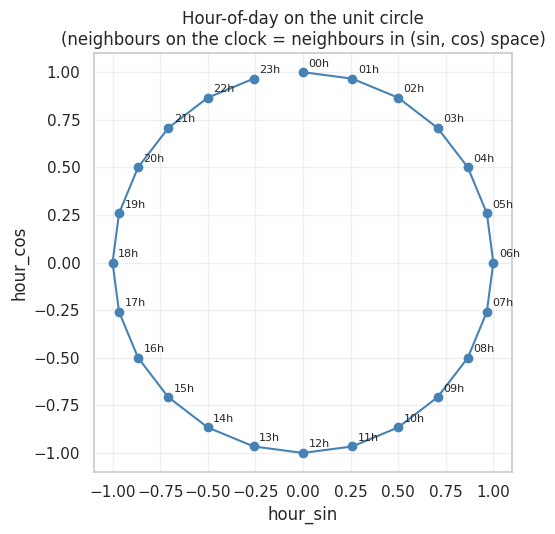

In [6]:
# Visualise the daily cycle on the (sin, cos) circle for one full day
one_day = df[df["datetime"].dt.date == pd.Timestamp("2014-06-15").date()]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(one_day["hour_sin"], one_day["hour_cos"], "o-", color="steelblue")
for _, r in one_day.iterrows():
    ax.annotate(f"{int(r['hour']):02d}h", (r["hour_sin"], r["hour_cos"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("hour_sin"); ax.set_ylabel("hour_cos")
ax.set_title("Hour-of-day on the unit circle\n(neighbours on the clock = neighbours in (sin, cos) space)")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Each dot on the unit circle is one hour of the day — they walk all the way around in 24 steps and return to the start, exactly as on a physical clock. The model sees this geometric structure directly through the `(hour_sin, hour_cos)` pair, and the same trick applies to month and day-of-week.

---
## 5. Wind direction — turning a compass into a 2-D vector

**Analogy.** Stand outside with a **weather vane**. Two pieces of information matter:

- **How fast** the wind blows (speed) &mdash; we already have this as `WSPM`.
- **Where the wind comes from** (direction) &mdash; this is in the `wd` column (a 16-point compass: N, NNE, NE, …) which we have **not used yet**.

For Beijing's **PM2.5**, direction matters as much as speed. The city sits between the **mountains to the north** (clean, low-PM air) and the **industrial corridor to the south** (heavy-PM air). A 5 m/s wind from the north and a 5 m/s wind from the south have *opposite effects* on downtown PM2.5, even though their `WSPM` values are identical.

We could one-hot-encode the 16 compass categories — 16 sparse columns. But there's a more compact, physically-natural representation: **decompose the wind into two components**, the meteorological standard:

$$ u = -\text{WSPM} \cdot \sin\theta, \qquad v = -\text{WSPM} \cdot \cos\theta, $$

where θ is the angle (clockwise from north) the wind comes from.

Convention:

- **`wind_u > 0`** &nbsp;&#8594;&nbsp; wind blows *eastward* (a westerly).
- **`wind_v > 0`** &nbsp;&#8594;&nbsp; wind blows *northward* (a southerly — the type that *carries industrial pollution toward Beijing*).
- **`wind_v < 0`** &nbsp;&#8594;&nbsp; wind blows *southward* (a northerly — *mountain air*).

Two new features instead of sixteen, and each one has a clear physical meaning. Our helper `fu.add_wind_components` handles the math; afterwards we drop the few rows where `wd` was missing.

In [7]:
df = fu.add_wind_components(df)
df = df.dropna(subset=["wind_u", "wind_v"]).reset_index(drop=True)

print(f"Rows after adding wind components: {len(df):,}  "
      f"(a few were dropped for missing wind direction)")
print(df[["datetime", "wd", "WSPM", "wind_u", "wind_v"]].head(6).round(2).to_string(index=False))

Rows after adding wind components: 33,114  (a few were dropped for missing wind direction)
           datetime  wd  WSPM  wind_u  wind_v
2013-03-01 00:00:00 NNW  5.70    2.18   -5.27
2013-03-01 01:00:00  NW  3.90    2.76   -2.76
2013-03-01 02:00:00 NNW  5.30    2.03   -4.90
2013-03-01 03:00:00   N  4.90   -0.00   -4.90
2013-03-01 04:00:00 NNW  3.20    1.22   -2.96
2013-03-01 05:00:00  NW  2.40    1.70   -1.70


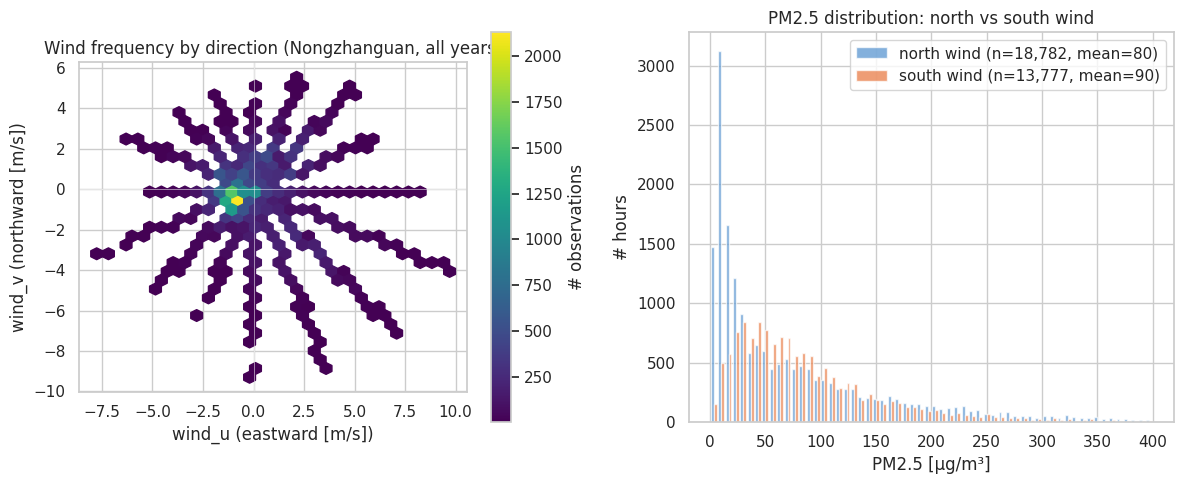

In [8]:
# Wind rose: scatter wind_v vs wind_u, colour by frequency
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

h2d = axes[0].hexbin(df["wind_u"], df["wind_v"], gridsize=30, cmap="viridis", mincnt=1)
axes[0].axhline(0, color="white", linewidth=0.6, alpha=0.6)
axes[0].axvline(0, color="white", linewidth=0.6, alpha=0.6)
axes[0].set_aspect("equal")
axes[0].set_xlabel("wind_u (eastward [m/s])")
axes[0].set_ylabel("wind_v (northward [m/s])")
axes[0].set_title("Wind frequency by direction (Nongzhanguan, all years)")
fig.colorbar(h2d, ax=axes[0], label="# observations")

# Mean PM2.5 by sign of wind_v (north-south component)
df_w = df.dropna(subset=["PM2.5"])
north_wind = df_w[df_w["wind_v"] < 0]["PM2.5"]
south_wind = df_w[df_w["wind_v"] > 0]["PM2.5"]
axes[1].hist([north_wind, south_wind], bins=60, range=(0, 400),
             label=[f"north wind (n={len(north_wind):,}, mean={north_wind.mean():.0f})",
                    f"south wind (n={len(south_wind):,}, mean={south_wind.mean():.0f})"],
             color=["#4E8FCE", "#E8743B"], alpha=0.7)
axes[1].set_xlabel("PM2.5 [\u00b5g/m\u00b3]")
axes[1].set_ylabel("# hours")
axes[1].set_title("PM2.5 distribution: north vs south wind")
axes[1].legend()
plt.tight_layout(); plt.show()

Two clear visual confirmations:

- **Wind rose (left).** The most frequent winds at Nongzhanguan come from the north and northeast (the lower half of the plot, `wind_v < 0`) — typical of Beijing's prevailing direction. There's also a secondary lobe of southerly winds.
- **PM2.5 histogram (right).** Two things stand out. First, **north winds bring many more 'very clean' hours** — that tall blue spike near zero is the mountain-air signal, and there is no comparable spike in orange. Second, the mean is higher under **south winds** (≈90 vs ≈80 &micro;g/m&sup3;). Both point the same way: south winds drag pollution from the industrial corridor into the city; north winds bring mountain air.

This single feature pair (`wind_u`, `wind_v`) lets the model see *where* the wind is, not just *how fast*.

---
## 6. The 15-feature minimum input set

Now that the engineering is done, we have in our DataFrame: the 11 raw numeric features (six pollutants + five meteo), two wind components, and six cyclic time features = **19 numeric columns** that could go into the model.

More features isn't automatically better. Dropping `PM10`, `SO2`, `CO`, and the *other* target pollutant leaves a **15-feature physically-motivated minimum** that matches the full 19-feature set on this dataset.

Each feature in the minimum has a clear job:

| Group | Features | Why it's there |
|---|---|---|
| target history | the target itself (PM2.5 or O&#8323;) | autoregressive signal |
| wind (vector) | `WSPM`, `wind_u`, `wind_v` | speed + direction = transport + dispersion |
| meteo | `TEMP`, `PRES`, `DEWP`, `RAIN` | atmospheric stability, washout |
| combustion proxy | `NO2` | traffic + heating activity (matters for both targets) |
| cyclic time | hour / month / day-of-week, sin/cos pairs | daily, seasonal, weekly rhythms |
| **total** | **15** | |

The helper `features_min(target)` returns this list for whichever target we are forecasting:

In [9]:
feats_pm25 = fu.features_min("PM2.5")
feats_o3   = fu.features_min("O3")

print(f"features_min('PM2.5')  ({len(feats_pm25)} features):")
print("  ", feats_pm25)
print(f"\nfeatures_min('O3')      ({len(feats_o3)} features):")
print("  ", feats_o3)

features_min('PM2.5')  (15 features):
   ['PM2.5', 'WSPM', 'wind_u', 'wind_v', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'NO2', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

features_min('O3')      (15 features):
   ['O3', 'WSPM', 'wind_u', 'wind_v', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'NO2', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


Both lists have **15 features** in the same order, with the target swapped in at position 0. From here on, `features_min(target)` is the input set we feed into the windowing step.

---
## 7. Building the sliding windows

With the engineered DataFrame and a chosen feature list, we now turn the long time series into many supervised (window, target) pairs.

The helper `fu.make_windows` slides a 24-hour window across the series and returns one (window, target) pair per step. It also handles one small subtlety from the cleaning step: when we dropped rows with missing values, the timeline gained small holes where some hours are simply absent. `make_windows` is **gap-aware** — it skips any window that would otherwise bridge across such a hole, so we never train on a sequence that pretends two rows separated by hours of missing data are consecutive.

We build windows for **PM2.5** at horizon ***h* = 1** using the 15-feature input set defined in Section 6.

In [10]:
T = 24    # window length: one full day of context
h = 1     # forecast horizon: 1 hour ahead

FEATURES = fu.features_min("PM2.5")

Xw, yw = fu.make_windows(df, FEATURES, target_col="PM2.5", T=T, h=h)

print(f"Window shape  : {Xw.shape}      ({Xw.shape[0]:,} windows of {T}h x {Xw.shape[2]} features)")
print(f"Target shape  : {yw.shape}")

n_naive = len(df) - T - h + 1
print(f"\nNaive count   : {n_naive:,} would-be windows")
print(f"Kept (no gaps): {len(Xw):,}")
print(f"Dropped       : {n_naive - len(Xw):,}  ({(n_naive - len(Xw))/n_naive*100:.1f}% spanned a gap)")

Window shape  : (23500, 24, 15)      (23,500 windows of 24h x 15 features)
Target shape  : (23500,)

Naive count   : 33,090 would-be windows
Kept (no gaps): 23,500
Dropped       : 9,590  (29.0% spanned a gap)


Nearly a third of would-be windows get dropped because they spanned a gap — without the gap check, those would have polluted training with sequences that aren't actually contiguous in time.

---
## 8. Chronological split — train / val / test

We have many (window, target) pairs. To evaluate any model honestly we need to **hold some pairs out** and only score on those. *How* we hold them out matters a lot for time series.

A random `train_test_split(..., shuffle=True)` would put some future rows in train and some past rows in test — the model would learn from the future and be scored on the past. That's **data leakage**, and test metrics under it are meaningless. The fix: **split chronologically** — the test set is the last chunk in time.

We use a **70 / 10 / 20 chronological split**:

| Set | Fraction | Time range | Purpose |
|---|---|---|---|
| Train | 70 % | first ≈2.8 years | fit model parameters |
| Validation | 10 % | next ≈4 months | early stopping, hyperparam choice |
| **Test** | **20 %** | **last ≈10 months** | final evaluation — **never seen before** |

The 20 % test fraction is the same convention used by classical-ML forecasting work on this dataset, which keeps results directly comparable later.

In [11]:
X_tr, y_tr, X_va, y_va, X_te, y_te = fu.chronological_split(Xw, yw)

print(f"train : {len(X_tr):>6,}  ({len(X_tr)/len(Xw)*100:.1f}%)")
print(f"val   : {len(X_va):>6,}  ({len(X_va)/len(Xw)*100:.1f}%)")
print(f"test  : {len(X_te):>6,}  ({len(X_te)/len(Xw)*100:.1f}%)")

train : 16,450  (70.0%)
val   :  2,350  (10.0%)
test  :  4,700  (20.0%)


Visualising where the splits fall on the calendar — that way we know *which weather and which pollution events* are in each set:

train  : 2013-03-02 00:00:00  ->  2015-12-18 11:00:00
val    : 2015-12-18 12:00:00  ->  2016-04-17 16:00:00
test   : 2016-04-17 17:00:00  ->  2017-02-25 17:00:00


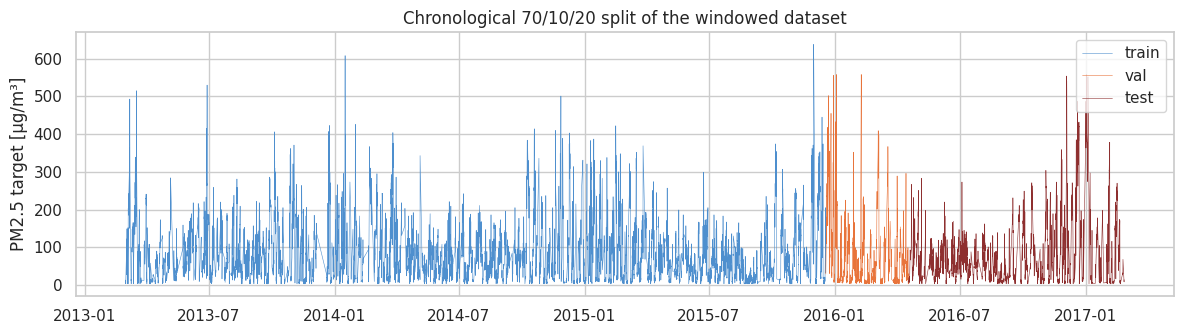

In [12]:
# Reconstruct the datetimes corresponding to each window's TARGET (= t+h)
from numpy.lib.stride_tricks import sliding_window_view

_dt_h = df["datetime"].diff().dt.total_seconds().div(3600).fillna(0).to_numpy()
_consec = (_dt_h == 1.0)
_n_total = len(df) - T - h + 1
_win_consec = sliding_window_view(_consec[1:], T + h - 1)[:_n_total]
_valid_idx = np.where(_win_consec.all(axis=1))[0]
win_target_dt = df["datetime"].iloc[_valid_idx + T + h - 1].reset_index(drop=True)

n_tr, n_va = len(X_tr), len(X_va)
split_train_end = win_target_dt.iloc[n_tr - 1]
split_val_end   = win_target_dt.iloc[n_tr + n_va - 1]
split_test_end  = win_target_dt.iloc[-1]

print(f"train  : {win_target_dt.iloc[0]}  ->  {split_train_end}")
print(f"val    : {win_target_dt.iloc[n_tr]}  ->  {split_val_end}")
print(f"test   : {win_target_dt.iloc[n_tr + n_va]}  ->  {split_test_end}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(win_target_dt.iloc[:n_tr],            yw[:n_tr],            color="#4E8FCE",  linewidth=0.4, label="train")
ax.plot(win_target_dt.iloc[n_tr:n_tr+n_va],   yw[n_tr:n_tr+n_va],   color="#E8743B",  linewidth=0.4, label="val")
ax.plot(win_target_dt.iloc[n_tr+n_va:],       yw[n_tr+n_va:],       color="#8E2F2F",  linewidth=0.4, label="test")
ax.set_ylabel("PM2.5 target [\u00b5g/m\u00b3]")
ax.set_title("Chronological 70/10/20 split of the windowed dataset")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

The test set is **the last ≈10 months** (spring 2016 into early 2017) — a stretch of weather and pollution the model will never see during training.

Notice: the validation set itself is also "the future" relative to training. We use it for tuning, but the *test* set is never touched until the very end.

---
## 9. Train-only standardisation

As in any ML pipeline, we fit `StandardScaler` **only on the training set** — fitting on all data would leak test statistics into preprocessing. We standardise both the **features X** and the **target y**:

- Features: each column gets mean 0, std 1 (per feature, computed across all train rows and time-steps).
- Target: PM2.5 also gets mean 0, std 1 *for training stability* — MSE loss on raw &micro;g/m&sup3; values gives gradients on the order of σ<sub>y</sub>² ≈ 6300, which can make training brittle. We invert the y-scaling at evaluation time so reported metrics are in original &micro;g/m&sup3;.

In [13]:
sx, sy = fu.fit_scalers(X_tr, y_tr)

Xs_tr = fu.scale_X(X_tr, sx); Xs_va = fu.scale_X(X_va, sx); Xs_te = fu.scale_X(X_te, sx)
ys_tr = sy.transform(y_tr.reshape(-1, 1)).flatten().astype(np.float32)
ys_va = sy.transform(y_va.reshape(-1, 1)).flatten().astype(np.float32)
ys_te = sy.transform(y_te.reshape(-1, 1)).flatten().astype(np.float32)

# Sanity check: train should have mean ~0, std ~1; test will differ
print("Train Xs mean (per feature, first 5): ", Xs_tr.reshape(-1, Xs_tr.shape[2]).mean(axis=0)[:5].round(3))
print("Train Xs std  (per feature, first 5): ", Xs_tr.reshape(-1, Xs_tr.shape[2]).std(axis=0)[:5].round(3))
print("\nTest Xs mean (NOT zero \u2014 distribution drift is real):")
print(Xs_te.reshape(-1, Xs_te.shape[2]).mean(axis=0)[:5].round(3))

Train Xs mean (per feature, first 5):  [ 0.  0. -0.  0. -0.]
Train Xs std  (per feature, first 5):  [1. 1. 1. 1. 1.]

Test Xs mean (NOT zero — distribution drift is real):
[-0.015 -0.047 -0.067  0.034  0.078]


Notice that **test mean is not zero**. That's expected — and important. It tells us the *test distribution differs from the train distribution*, which is true for every real time series (the future is never identically distributed to the past). Our scaler doesn't try to hide this; it just uses train statistics, and test data is mapped accordingly.

The arrays `Xs_tr`, `Xs_va`, `Xs_te` (standardised features) and `ys_tr`, `ys_va`, `ys_te` (standardised targets) are now ready to feed into any forecasting model. Predictions in the standardised target space will need an `sy.inverse_transform` step to come back to &micro;g/m&sup3; for evaluation.

---
## Recap

Starting from the raw Beijing hourly CSV, we have:

1. **Loaded and cleaned** Nongzhanguan station — `load_clean_station` parses datetime, sorts chronologically, drops rows with any missing numeric value.
2. **Engineered cyclic time features** — hour, month, day-of-week as sin/cos pairs so the clock structure is preserved.
3. **Decomposed wind** from compass direction into east-west and north-south components — physically natural and dense.
4. **Selected a 15-feature minimum** input set: target history, wind (speed + direction), four meteo channels, NO&#8322; combustion proxy, and six cyclic time features.
5. **Built sliding windows** of *T* = 24 hours with horizon *h* = 1, using gap-aware logic so no window straddles a missing-row gap.
6. **Split chronologically** 70 / 10 / 20 — train, validation, test are temporally ordered, *never shuffled*. The 20 % test slice matches the convention used by classical-ML benchmarks on this dataset.
7. **Standardised** features and target with statistics fit on the training set only — no leakage from the future.

We have not yet computed any predictions or metrics. That is the next notebook's job: build **naive forecasting models** so every later result has a number to be compared against.

### Check your understanding

1. Why is `train_test_split(..., shuffle=True)` a bad idea for time-series data? What concrete kind of error does it cause in the test metrics?
2. We standardised the **target** *y*, not just the features **X**. Why? And what step do we need at evaluation time to get metrics back in &micro;g/m&sup3;?
3. Encoding `hour` as `sin/cos` introduces *two* features instead of one. Why do we need both? What goes wrong if we only use `sin`?
4. We could have one-hot-encoded the 16-point compass `wd` (16 sparse columns). Instead we used `wind_u, wind_v` (2 dense columns). Beyond compactness, what *additional* information does the (u, v) representation carry that 16 indicator columns do not?
5. The 15-feature minimum drops PM10, SO2, CO and the *other* pollutant we are not predicting. Why is that not a problem in practice — and which group of features in our minimum compensates for the missing pollutants?

*(Answers: 1 — the model sees future days during training, so test metrics describe a leaky fantasy with no operational meaning. 2 — training stability: MSE on raw &micro;g/m&sup3; gives gradients of size σ<sub>y</sub>² in the thousands, which destabilises optimisation; we inverse-transform predictions before computing MAE / RMSE / R&sup2;. 3 — sin alone is not invertible: hour 3 and hour 9 both have sin ≈ +0.71 but opposite cos (+0.71 vs −0.71). Both together give a unique point on the circle. 4 — one-hot drops the wind speed; (u, v) **multiplies** direction by `WSPM` so a stronger wind from the same direction gets a larger vector. The model also gets a smooth, continuous representation — 5 m/s NNE is close to 5 m/s NE in (u, v) space, but in one-hot land they share zero columns. 5 — the dropped pollutants are **highly correlated** with what we keep (PM10 with PM2.5, NO2/CO with traffic patterns). NO&#8322; is kept as the combustion proxy; the cyclic time features encode rush-hour and seasonal patterns that the dropped pollutants would also reflect.)*